In [1]:
import pandas as pd

file_path = "data/bank/bank-full.csv"
df = pd.read_csv(file_path, sep=';')

print(df.shape)
print(df.head())

(45211, 17)
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  


In [2]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [3]:
df.duplicated().sum()

np.int64(0)

In [4]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,           
    stratify=df['y'],         
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,            
    stratify=temp_df['y'],
    random_state=42
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (31647, 17)
Validation: (6782, 17)
Test: (6782, 17)


In [5]:
train_df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,31647.000000,31647.000000,31647.000000,31647.000000,31647.000000,31647.000000,31647.000000
mean,40.883022,1363.589535,15.806712,258.755143,2.760040,39.869498,0.584795
std,10.621809,3070.235315,8.331080,259.880162,3.104999,99.674113,2.490925
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,74.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,451.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1427.500000,21.000000,318.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [6]:
print(train_df['y'].value_counts())
print(100*train_df['y'].value_counts()/len(train_df['y']))


y
no     27945
yes     3702
Name: count, dtype: int64
y
no     88.302209
yes    11.697791
Name: count, dtype: float64


In [7]:
train_proc = train_df.copy()

In [8]:
train_proc.drop(["day","month"],axis =1, inplace = True)
val_df.drop(["day","month"],axis =1, inplace = True)
test_df.drop(["day","month"],axis =1, inplace = True)


In [9]:
import numpy as np

cat_cols = ['job', 'marital', 'education']

for df in [train_proc, val_df, test_df]:
    for i in train_proc.columns:
        df[i] = np.where(df[i] == "unknown", np.nan, df[i])
        
train_proc.isna().sum()

age              0
job            206
marital          0
education     1314
default          0
balance          0
housing          0
loan             0
contact       9100
duration         0
campaign         0
pdays            0
previous         0
poutcome     25917
y                0
dtype: int64

In [10]:
print((train_proc['job'].isna().sum()/train_proc.poutcome.shape[0])*100)
print((train_proc['education'].isna().sum()/train_proc.poutcome.shape[0])*100)
print((train_proc['contact'].isna().sum()/train_proc.poutcome.shape[0])*100)
print((train_proc['poutcome'].isna().sum()/train_proc.poutcome.shape[0])*100)

0.6509305779378772
4.152052327234809
28.754700287547003
81.89401839036876


In [11]:
train_proc.drop("poutcome", inplace = True, axis = 1)
train_proc.drop("contact", inplace = True, axis = 1)

val_df.drop("poutcome", inplace = True, axis = 1)
val_df.drop("contact", inplace = True, axis = 1)

test_df.drop("poutcome", inplace = True, axis = 1)
test_df.drop("contact", inplace = True, axis = 1)


In [12]:
train_proc["job"] = train_proc["job"].ffill()
train_proc["education"] = train_proc["education"].ffill()

val_df["job"] = val_df["job"].ffill()
val_df["education"] = val_df["education"].ffill()

test_df["job"] = test_df["job"].ffill()
test_df["education"] = test_df["education"].ffill()

In [13]:
binary=['default','housing','loan','y']
def binary_to_num(x):
    if x == "yes":
        return 1
    else:
        return 0
for i in binary:
    train_proc[i] = train_proc[i].apply(binary_to_num)
    
    val_df[i] = val_df[i].apply(binary_to_num)
    test_df[i] = test_df[i].apply(binary_to_num)

In [14]:
train_proc.head()

,age,job,marital,education,default,balance,housing,loan,duration,campaign,pdays,previous,y
13382,31.0,services,married,secondary,0,1.0,1,0,82.0,1.0,-1.0,0.0,0
32641,35.0,services,married,secondary,0,195.0,1,0,203.0,1.0,-1.0,0.0,0
3991,24.0,blue-collar,single,secondary,0,77.0,1,0,236.0,2.0,-1.0,0.0,0
8068,35.0,blue-collar,married,secondary,0,80.0,1,1,579.0,2.0,-1.0,0.0,0
27484,37.0,services,single,secondary,0,105.0,0,1,197.0,2.0,157.0,4.0,0


In [15]:
import pandas as pd

cat_cols = ['job', 'marital', 'education']

all_df = pd.concat([train_proc, val_df, test_df], axis=0)

all_df = pd.get_dummies(all_df, columns=cat_cols, drop_first=True, dtype=int)

train_proc = all_df.iloc[:len(train_proc)]
val_df = all_df.iloc[len(train_proc):len(train_proc)+len(val_df)]
test_df = all_df.iloc[len(train_proc)+len(val_df):]

In [16]:
train_proc.head()

,age,default,balance,housing,loan,duration,campaign,pdays,previous,y,...,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,marital_married,marital_single,education_secondary,education_tertiary
13382,31.0,0,1.0,1,0,82.0,1.0,-1.0,0.0,0,...,0,0,1,0,0,0,1,0,1,0
32641,35.0,0,195.0,1,0,203.0,1.0,-1.0,0.0,0,...,0,0,1,0,0,0,1,0,1,0
3991,24.0,0,77.0,1,0,236.0,2.0,-1.0,0.0,0,...,0,0,0,0,0,0,0,1,1,0
8068,35.0,0,80.0,1,1,579.0,2.0,-1.0,0.0,0,...,0,0,0,0,0,0,1,0,1,0
27484,37.0,0,105.0,0,1,197.0,2.0,157.0,4.0,0,...,0,0,1,0,0,0,0,1,1,0


<Axes: >

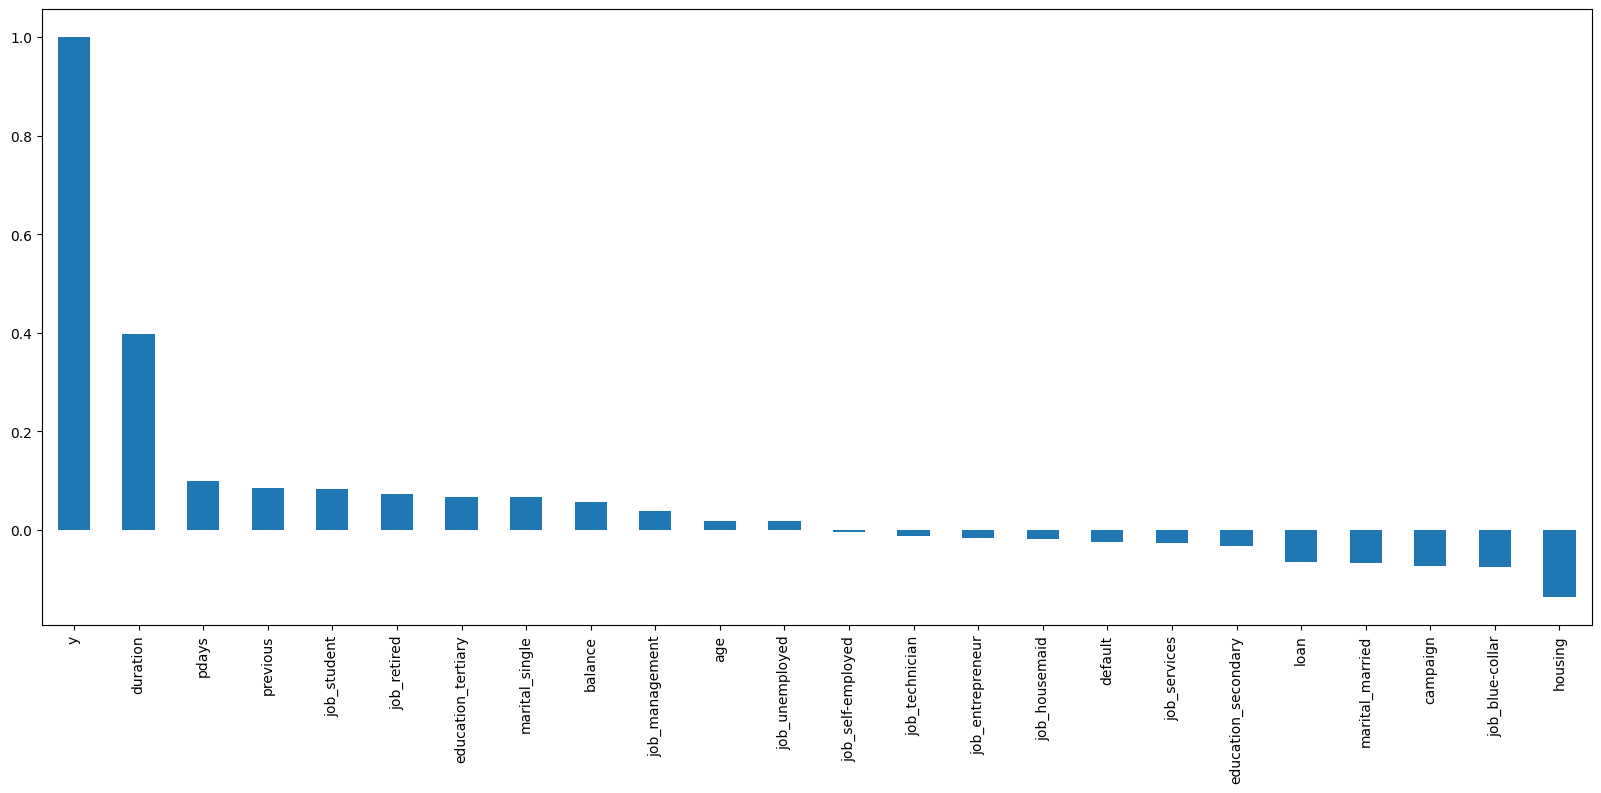

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20,8))

train_proc.corr()['y'].sort_values(ascending = False).plot(kind='bar')

In [18]:
# train_proc['first_contact'] = (train_proc['pdays'] == -1).astype(int)
# val_df['first_contact'] = (val_df['pdays'] == -1).astype(int)
# test_df['first_contact'] = (test_df['pdays'] == -1).astype(int)

In [18]:
cat_cols = train_proc.select_dtypes(include=['object']).columns.tolist()
num_cols = train_proc.select_dtypes(include=['int64','float64']).columns.tolist()

In [19]:

import time
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb

from xgboost import XGBClassifier, plot_importance
from sklearn.metrics import accuracy_score, classification_report, log_loss
from sklearn.utils import compute_sample_weight
from sklearn.model_selection import GridSearchCV

X_train = train_proc.drop(columns=['y'])
X_val   = val_df.drop(columns=['y'])
X_test  = test_df.drop(columns=['y'])

y_train = train_proc['y']
y_val   = val_df['y']
y_test  = test_df['y']

In [ ]:
from sklearn.model_selection import GridSearchCV

from xgboost import XGBClassifier

xgb_clf = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    n_estimators=300,
    seed=42
)

param_grid = {
    'learning_rate': [0.01, 0.1],
    'max_depth': [4,6,8],
    'subsample': [0.6,0.8,1.0],
    'reg_alpha': [0,0.1],
    'reg_lambda': [1,5]
}

grid = GridSearchCV(
    xgb_clf,
    param_grid,
    scoring='f1',
    cv=3,
    verbose=1,
    n_jobs=-1
)

start = time.time()
grid.fit(X_train, y_train)
print("GridSearch Time:", time.time()-start)
print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Fitting 3 folds for each of 72 candidates, totalling 216 fits


/home/sx2394/miniconda3/envs/omni/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/home/sx2394/miniconda3/envs/omni/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [20:37:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/sx2394/miniconda3/envs/omni/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [20:37:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/sx2394/miniconda3/envs/omni/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [20:37:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


GridSearch Time: 461.3688099384308
Best Params: {'learning_rate': 0.1, 'max_depth': 4, 'reg_alpha': 0, 'reg_lambda': 5, 'subsample': 0.8}
Best CV Score: 0.4681319117625231


In [20]:
import xgboost as xgb
from sklearn.utils import compute_sample_weight
from sklearn.metrics import accuracy_score, classification_report
import time

# 1. 准备 DMatrix
weights = compute_sample_weight(class_weight='balanced', y=y_train)

dtrain = xgb.DMatrix(X_train, label=y_train, weight=weights)
dval   = xgb.DMatrix(X_val, label=y_val)

evals = [(dtrain, 'train'), (dval, 'validation')]

# 2. 设置参数
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'max_depth': 4,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'reg_alpha': 0,
    'reg_lambda': 5,
    'seed': 42
}

# 3. 训练
start = time.time()
evals_result = {}  # 用于记录 loss
bst = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=1500,
    evals=evals,
    early_stopping_rounds=50,
    evals_result=evals_result,
    verbose_eval=False
)
print("Training time:", time.time() - start)
print("Best iteration:", bst.best_iteration)


Training time: 7.43291974067688
Best iteration: 1491


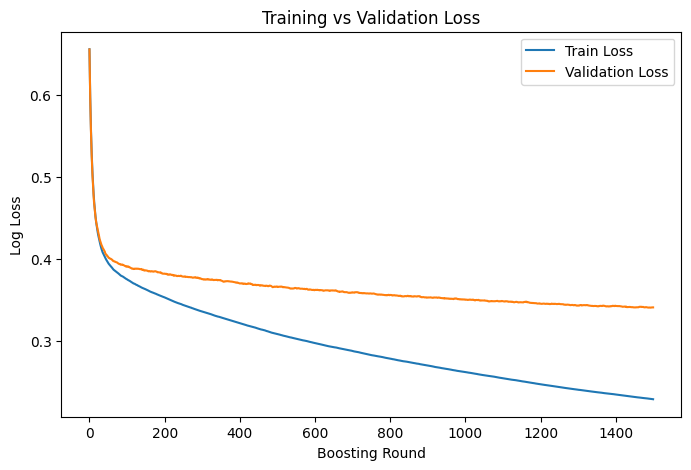

In [21]:
import matplotlib.pyplot as plt

train_loss = evals_result['train']['logloss']
val_loss   = evals_result['validation']['logloss']

plt.figure(figsize=(8,5))
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Boosting Round')
plt.ylabel('Log Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [22]:
# dtest = xgb.DMatrix(X_test)
# y_val_pred = (bst.predict(dval) > 0.5).astype(int)
# y_test_pred = (bst.predict(dtest) > 0.5).astype(int)

# print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
# print(classification_report(y_val, y_val_pred))

# print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
# print(classification_report(y_test, y_test_pred))

from sklearn.metrics import accuracy_score, classification_report, average_precision_score

# DMatrix
dtest = xgb.DMatrix(X_test)

# 预测概率
y_val_prob = bst.predict(dval)   # 输出概率
y_test_prob = bst.predict(dtest)

# 二值预测
y_val_pred = (y_val_prob > 0.5).astype(int)
y_test_pred = (y_test_prob > 0.5).astype(int)

# Accuracy & classification report
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

# AUC-PR
val_auc_pr = average_precision_score(y_val, y_val_prob)
test_auc_pr = average_precision_score(y_test, y_test_prob)
print("Validation AUC-PR:", val_auc_pr)
print("Test AUC-PR:", test_auc_pr)

Validation Accuracy: 0.8484222943084636
              precision    recall  f1-score   support

           0       0.96      0.86      0.91      5988
           1       0.42      0.73      0.53       794

    accuracy                           0.85      6782
   macro avg       0.69      0.80      0.72      6782
weighted avg       0.90      0.85      0.87      6782

Test Accuracy: 0.8382483043350044
              precision    recall  f1-score   support

           0       0.96      0.85      0.90      5989
           1       0.40      0.72      0.51       793

    accuracy                           0.84      6782
   macro avg       0.68      0.79      0.71      6782
weighted avg       0.89      0.84      0.86      6782

Validation AUC-PR: 0.4986222116782371
Test AUC-PR: 0.4903632353586712


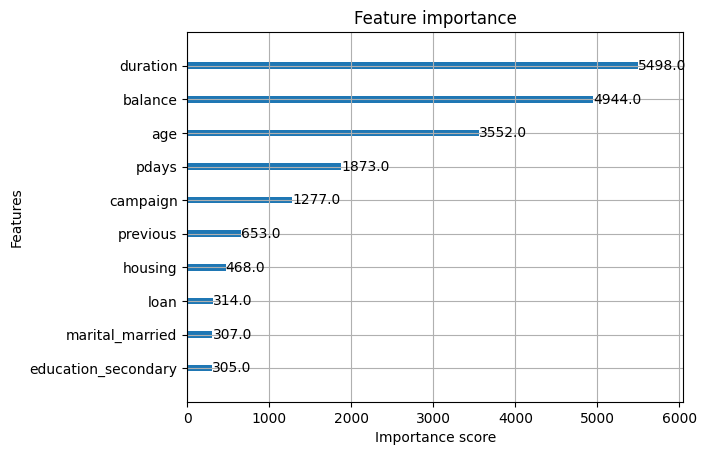

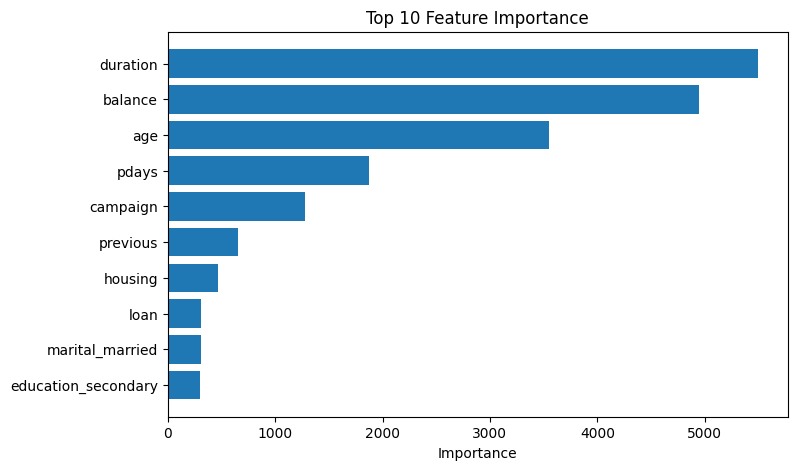

In [23]:
xgb.plot_importance(bst, max_num_features=10)
plt.show()

import numpy as np

importances = bst.get_score(importance_type='weight')
top_features = sorted(importances.items(), key=lambda x: x[1], reverse=True)[:10]
names, scores = zip(*top_features)

plt.figure(figsize=(8,5))
plt.barh(names, scores)
plt.xlabel('Importance')
plt.title('Top 10 Feature Importance')
plt.gca().invert_yaxis()
plt.show()

In [32]:
learning_rates = [0.01, 0.1, 0.3]
metrics_results = {} 

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

for lr in learning_rates:
    print(f"Training with learning_rate = {lr}")
    params['learning_rate'] = lr

    bst_lr = xgb.train(
        params=params,
        dtrain=dtrain,
        num_boost_round=500,
        evals=[(dval,'validation')],
        early_stopping_rounds=30,
        verbose_eval=False
    )

    # 预测
    y_val_prob = bst_lr.predict(dval)
    y_val_pred = (y_val_prob > 0.5).astype(int)

    # 计算指标
    metrics_results[lr] = {
        'accuracy': accuracy_score(y_val, y_val_pred),
        'precision': precision_score(y_val, y_val_pred, zero_division=0),
        'recall': recall_score(y_val, y_val_pred, zero_division=0),
        'f1': f1_score(y_val, y_val_pred, zero_division=0),
        'auc': roc_auc_score(y_val, y_val_prob)
    }

Training with learning_rate = 0.01
Training with learning_rate = 0.1
Training with learning_rate = 0.3


In [34]:
import pandas as pd

df_metrics = pd.DataFrame(metrics_results).T  # lr 为行，指标为列
print(df_metrics)

      accuracy  precision    recall        f1       auc
0.01  0.827632   0.389250  0.829975  0.529956  0.902761
0.10  0.860218   0.438986  0.697733  0.538911  0.885857
0.30  0.866559   0.447493  0.595718  0.511075  0.869012


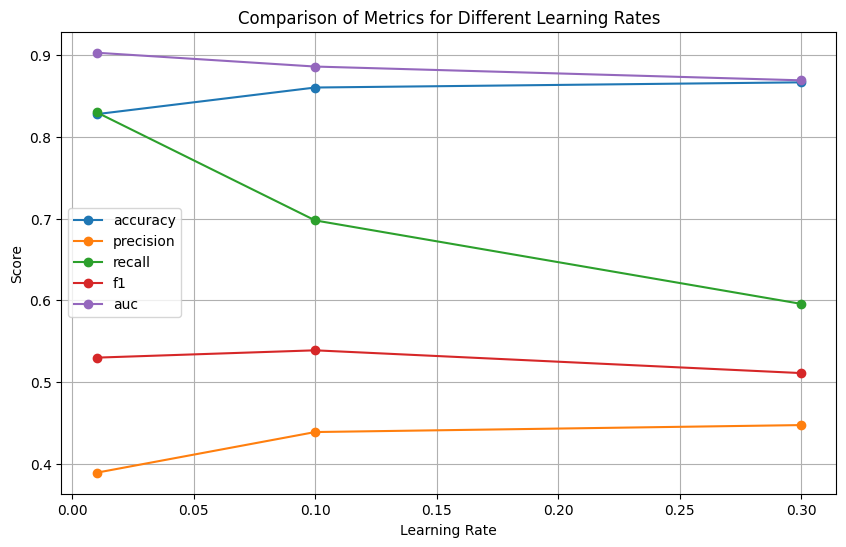

In [35]:
plt.figure(figsize=(10,6))

for metric in ['accuracy','precision','recall','f1','auc']:
    plt.plot(df_metrics.index, df_metrics[metric], marker='o', label=metric)

plt.xlabel('Learning Rate')
plt.ylabel('Score')
plt.title('Comparison of Metrics for Different Learning Rates')
plt.legend()
plt.grid(True)
plt.show()

In [24]:
import xgboost as xgb
from sklearn.utils import compute_sample_weight
from sklearn.metrics import accuracy_score, classification_report
import time

# 1. 准备 DMatrix
weights = compute_sample_weight(class_weight='balanced', y=y_train)

dtrain = xgb.DMatrix(X_train, label=y_train, weight=weights)
dval   = xgb.DMatrix(X_val, label=y_val)

evals = [(dtrain, 'train'), (dval, 'validation')]

# 2. 设置参数
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'max_depth': 4,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'reg_alpha': 0,
    'reg_lambda': 5,
    'seed': 42
}

# 3. 训练
start = time.time()
evals_result = {}  # 用于记录 loss
bst = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=3000,
    evals=evals,
    early_stopping_rounds=50,
    evals_result=evals_result,
    verbose_eval=False
)
print("Training time:", time.time() - start)
print("Best iteration:", bst.best_iteration)


from sklearn.metrics import accuracy_score, classification_report, average_precision_score
import xgboost as xgb

# 构造 DMatrix
dtest = xgb.DMatrix(X_test)

# 预测概率
y_val_prob = bst.predict(dval)   # 输出概率
y_test_prob = bst.predict(dtest)

# 二值预测
y_val_pred = (y_val_prob > 0.5).astype(int)
y_test_pred = (y_test_prob > 0.5).astype(int)

# Accuracy & classification report
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

# AUC-PR
val_auc_pr = average_precision_score(y_val, y_val_prob)
test_auc_pr = average_precision_score(y_test, y_test_prob)
print("Validation AUC-PR:", val_auc_pr)
print("Test AUC-PR:", test_auc_pr)

Training time: 11.68222451210022
Best iteration: 2178
Validation Accuracy: 0.8521085225597169
              precision    recall  f1-score   support

           0       0.96      0.87      0.91      5988
           1       0.42      0.70      0.52       794

    accuracy                           0.85      6782
   macro avg       0.69      0.78      0.72      6782
weighted avg       0.89      0.85      0.87      6782

Test Accuracy: 0.8428192273665586
              precision    recall  f1-score   support

           0       0.95      0.86      0.91      5989
           1       0.40      0.69      0.51       793

    accuracy                           0.84      6782
   macro avg       0.68      0.78      0.71      6782
weighted avg       0.89      0.84      0.86      6782

Validation AUC-PR: 0.4895795941405631
Test AUC-PR: 0.47852829131614744


In [26]:
import xgboost as xgb
from sklearn.utils import compute_sample_weight
from sklearn.metrics import accuracy_score, classification_report
import time

# 1. 准备 DMatrix
weights = compute_sample_weight(class_weight='balanced', y=y_train)

dtrain = xgb.DMatrix(X_train, label=y_train, weight=weights)
dval   = xgb.DMatrix(X_val, label=y_val)

evals = [(dtrain, 'train'), (dval, 'validation')]

# 2. 设置参数
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'max_depth': 4,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'reg_alpha': 0,
    'reg_lambda': 5,
    'seed': 42
}

# 3. 训练
start = time.time()
evals_result = {}  # 用于记录 loss
bst = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=500,
    evals=evals,
    early_stopping_rounds=50,
    evals_result=evals_result,
    verbose_eval=False
)
print("Training time:", time.time() - start)
print("Best iteration:", bst.best_iteration)


# 构造 DMatrix
dtest = xgb.DMatrix(X_test)

# 预测概率
y_val_prob = bst.predict(dval)   # 输出概率
y_test_prob = bst.predict(dtest)

# 二值预测
y_val_pred = (y_val_prob > 0.5).astype(int)
y_test_pred = (y_test_prob > 0.5).astype(int)

# Accuracy & classification report
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

# AUC-PR
val_auc_pr = average_precision_score(y_val, y_val_prob)
test_auc_pr = average_precision_score(y_test, y_test_prob)
print("Validation AUC-PR:", val_auc_pr)
print("Test AUC-PR:", test_auc_pr)

Training time: 2.3619608879089355
Best iteration: 488
Validation Accuracy: 0.8352993217340018
              precision    recall  f1-score   support

           0       0.97      0.84      0.90      5988
           1       0.40      0.81      0.53       794

    accuracy                           0.84      6782
   macro avg       0.69      0.82      0.72      6782
weighted avg       0.90      0.84      0.86      6782

Test Accuracy: 0.8230610439398408
              precision    recall  f1-score   support

           0       0.97      0.83      0.89      5989
           1       0.38      0.78      0.51       793

    accuracy                           0.82      6782
   macro avg       0.67      0.80      0.70      6782
weighted avg       0.90      0.82      0.85      6782

Validation AUC-PR: 0.5239112994274455
Test AUC-PR: 0.5033303280635906


**MLP**

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, average_precision_score, classification_report
from sklearn.utils import compute_sample_weight

# --------------------------
# 1. 特征标准化
# --------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# 样本权重（平衡类别）
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

In [ ]:


# --------------------------
# 2. 定义实验参数
# --------------------------
hidden_layers_list = [(64,), (128, 64), (256, 128, 64)]
activations = ['relu', 'tanh']
learning_rates = [0.001, 0.01, 0.1]
max_iter = 500

# 用于记录结果
results = []

# --------------------------
# 3. 遍历参数组合
# --------------------------
for hidden_layers in hidden_layers_list:
    for activation in activations:
        for lr in learning_rates:
            print(f"Training MLP: layers={hidden_layers}, activation={activation}, lr={lr}")
            start= time.time()
            mlp = MLPClassifier(
                hidden_layer_sizes=hidden_layers,
                activation=activation,
                solver='adam',
                learning_rate_init=lr,
                max_iter=max_iter,
                random_state=42,
                verbose=False
            )
            
            mlp.fit(X_train_scaled, y_train, sample_weight=sample_weights)
            training_time = time.time() - start
            print(f"Training completed in {training_time:.2f} seconds.")
            # 验证集预测
            y_val_pred = mlp.predict(X_val_scaled)
            y_val_proba = mlp.predict_proba(X_val_scaled)[:, 1]
            
            # 测试集预测
            y_test_pred = mlp.predict(X_test_scaled)
            y_test_proba = mlp.predict_proba(X_test_scaled)[:, 1]
            
            # 验证集指标
            val_metrics = {
                'accuracy': accuracy_score(y_val, y_val_pred),
                'precision': precision_score(y_val, y_val_pred),
                'recall': recall_score(y_val, y_val_pred),
                'f1': f1_score(y_val, y_val_pred),
                'auc_pr': average_precision_score(y_val, y_val_proba),
            }
            
            # 测试集指标
            test_metrics = {
                'accuracy': accuracy_score(y_test, y_test_pred),
                'precision': precision_score(y_test, y_test_pred),
                'recall': recall_score(y_test, y_test_pred),
                'f1': f1_score(y_test, y_test_pred),
                'auc_pr': average_precision_score(y_test, y_test_proba)
            }
            
            # 记录结果
            results.append({
                'hidden_layers': hidden_layers,
                'activation': activation,
                'learning_rate': lr,
                'val_metrics': val_metrics,
                'test_metrics': test_metrics,
                'loss_curve': mlp.loss_curve_,
                'training_time': training_time
            })
            
            print(f"Hidden layers: {hidden_layers}, Activation: {activation}, Learning rate: {lr}")
            print("Validation metrics:")
            for metric_name, value in val_metrics.items():
                print(f"  {metric_name}: {value:.4f}")
            print("Test metrics:")
            for metric_name, value in test_metrics.items():
                print(f"  {metric_name}: {value:.4f}")
            print("-"*50)


Training MLP: layers=(64,), activation=relu, lr=0.001
Training completed in 14.17 seconds.
Hidden layers: (64,), Activation: relu, Learning rate: 0.001
Validation metrics:
  accuracy: 0.8046
  precision: 0.3544
  recall: 0.8136
  f1: 0.4937
  auc_pr: 0.4767
Test metrics:
  accuracy: 0.7952
  precision: 0.3386
  recall: 0.7881
  f1: 0.4737
  auc_pr: 0.4648
--------------------------------------------------
Training MLP: layers=(64,), activation=relu, lr=0.01
Training completed in 10.03 seconds.
Hidden layers: (64,), Activation: relu, Learning rate: 0.01
Validation metrics:
  accuracy: 0.8210
  precision: 0.3727
  recall: 0.7746
  f1: 0.5033
  auc_pr: 0.4421
Test metrics:
  accuracy: 0.8098
  precision: 0.3541
  recall: 0.7604
  f1: 0.4832
  auc_pr: 0.4380
--------------------------------------------------
Training MLP: layers=(64,), activation=relu, lr=0.1
Training completed in 1.60 seconds.
Hidden layers: (64,), Activation: relu, Learning rate: 0.1
Validation metrics:
  accuracy: 0.781

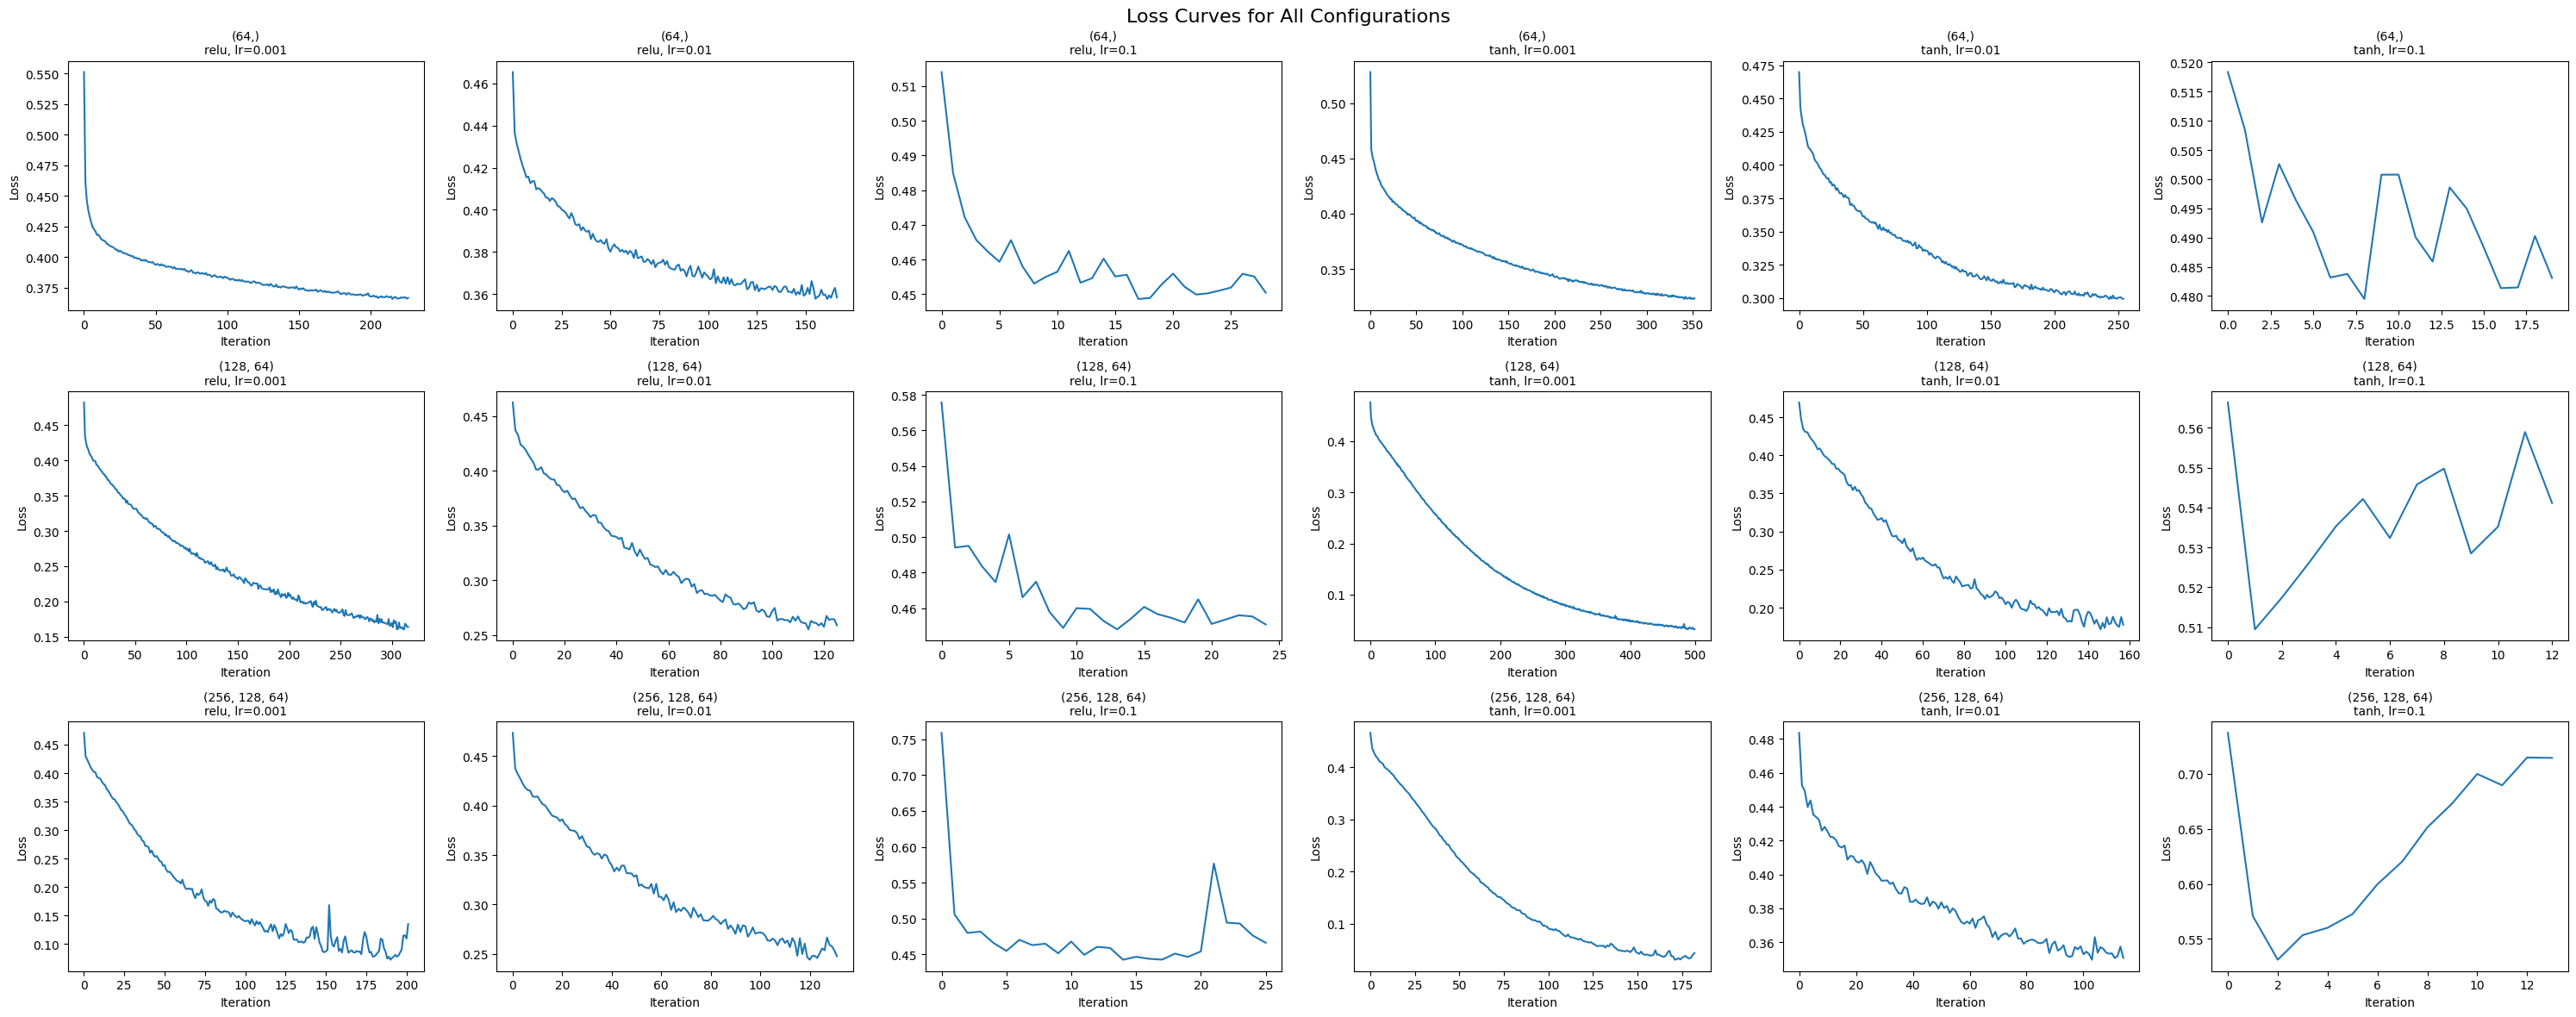

In [48]:
import matplotlib.pyplot as plt
import math

n = len(results)
cols = 6   # 每行放3个
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*4))
axes = axes.flatten()

for i, r in enumerate(results):
    ax = axes[i]
    
    ax.plot(r['loss_curve'])
    
    title = f"{r['hidden_layers']}\n{r['activation']}, lr={r['learning_rate']}"
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Loss')

# 删除多余子图
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Loss Curves for All Configurations', fontsize=16)
plt.tight_layout()
plt.show()

In [28]:
hidden_layers=(64,)
activation='relu'
lr=0.01
max_iter = 500
start = time.time()
mlp = MLPClassifier(
    hidden_layer_sizes=hidden_layers,
    activation=activation,
    solver='adam',
    learning_rate_init=lr,
    max_iter=max_iter,
    random_state=42,
    verbose=False
)

mlp.fit(X_train_scaled, y_train, sample_weight=sample_weights)
training_time = time.time() - start
print(f"Training completed in {training_time:.2f} seconds.")
# 验证集预测
y_val_pred = mlp.predict(X_val_scaled)
y_val_proba = mlp.predict_proba(X_val_scaled)[:, 1]

# 测试集预测
y_test_pred = mlp.predict(X_test_scaled)
y_test_proba = mlp.predict_proba(X_test_scaled)[:, 1]

# 验证集指标
val_metrics = {
    'accuracy': accuracy_score(y_val, y_val_pred),
    'precision': precision_score(y_val, y_val_pred),
    'recall': recall_score(y_val, y_val_pred),
    'f1': f1_score(y_val, y_val_pred),
    'auc_pr': average_precision_score(y_val, y_val_proba),
}
print(f"Validation Accuracy: {val_metrics['accuracy']:.4f}, precision: {val_metrics['precision']:.4f}, recall: {val_metrics['recall']:.4f}, f1: {val_metrics['f1']:.4f}, auc_pr: {val_metrics['auc_pr']:.4f}")
# 测试集指标
test_metrics = {
    'accuracy': accuracy_score(y_test, y_test_pred),
    'precision': precision_score(y_test, y_test_pred),
    'recall': recall_score(y_test, y_test_pred),
    'f1': f1_score(y_test, y_test_pred),
    'auc_pr': average_precision_score(y_test, y_test_proba)
}
print(f"Test Accuracy: {test_metrics['accuracy']:.4f}, precision: {test_metrics['precision']:.4f}, recall: {test_metrics['recall']:.4f}, f1: {test_metrics['f1']:.4f}, auc_pr: {test_metrics['auc_pr']:.4f}")

Training completed in 10.13 seconds.
Validation Accuracy: 0.8210, precision: 0.3727, recall: 0.7746, f1: 0.5033, auc_pr: 0.4421
Test Accuracy: 0.8098, precision: 0.3541, recall: 0.7604, f1: 0.4832, auc_pr: 0.4380


In [ ]:
hidden_layers=(64,)
activation='relu'
lr=0.01
max_iter = 1000
start = time.time()
mlp = MLPClassifier(
    hidden_layer_sizes=hidden_layers,
    activation=activation,
    solver='adam',
    learning_rate_init=lr,
    max_iter=max_iter,
    random_state=42,
    verbose=False
)

mlp.fit(X_train_scaled, y_train, sample_weight=sample_weights)
training_time = time.time() - start
print(f"Training completed in {training_time:.2f} seconds.")
# 验证集预测
y_val_pred = mlp.predict(X_val_scaled)
y_val_proba = mlp.predict_proba(X_val_scaled)[:, 1]

# 测试集预测
y_test_pred = mlp.predict(X_test_scaled)
y_test_proba = mlp.predict_proba(X_test_scaled)[:, 1]



Training completed in 10.09 seconds.
Validation Accuracy: 0.8210, precision: 0.3727, recall: 0.7746, f1: 0.5033
Test Accuracy: 0.8098, precision: 0.3541, recall: 0.7604, f1: 0.4832


In [30]:
# 验证集指标
val_metrics = {
    'accuracy': accuracy_score(y_val, y_val_pred),
    'precision': precision_score(y_val, y_val_pred),
    'recall': recall_score(y_val, y_val_pred),
    'f1': f1_score(y_val, y_val_pred),
    'auc_pr': average_precision_score(y_val, y_val_proba),
}
print(f"Validation Accuracy: {val_metrics['accuracy']:.4f}, precision: {val_metrics['precision']:.4f}, recall: {val_metrics['recall']:.4f}, f1: {val_metrics['f1']:.4f}, auc_pr: {val_metrics['auc_pr']:.4f}")
# 测试集指标
test_metrics = {
    'accuracy': accuracy_score(y_test, y_test_pred),
    'precision': precision_score(y_test, y_test_pred),
    'recall': recall_score(y_test, y_test_pred),
    'f1': f1_score(y_test, y_test_pred),
    'auc_pr': average_precision_score(y_test, y_test_proba)
}
print(f"Test Accuracy: {test_metrics['accuracy']:.4f}, precision: {test_metrics['precision']:.4f}, recall: {test_metrics['recall']:.4f}, f1: {test_metrics['f1']:.4f}, auc_pr: {test_metrics['auc_pr']:.4f}")

Validation Accuracy: 0.8210, precision: 0.3727, recall: 0.7746, f1: 0.5033, auc_pr: 0.4421
Test Accuracy: 0.8098, precision: 0.3541, recall: 0.7604, f1: 0.4832, auc_pr: 0.4380


In [31]:
hidden_layers=(64,)
activation='relu'
lr=0.01
max_iter = 2000
start = time.time()
mlp = MLPClassifier(
    hidden_layer_sizes=hidden_layers,
    activation=activation,
    solver='adam',
    learning_rate_init=lr,
    max_iter=max_iter,
    random_state=42,
    verbose=False
)

mlp.fit(X_train_scaled, y_train, sample_weight=sample_weights)
training_time = time.time() - start
print(f"Training completed in {training_time:.2f} seconds.")
# 验证集预测
y_val_pred = mlp.predict(X_val_scaled)
y_val_proba = mlp.predict_proba(X_val_scaled)[:, 1]

# 测试集预测
y_test_pred = mlp.predict(X_test_scaled)
y_test_proba = mlp.predict_proba(X_test_scaled)[:, 1]


val_metrics = {
    'accuracy': accuracy_score(y_val, y_val_pred),
    'precision': precision_score(y_val, y_val_pred),
    'recall': recall_score(y_val, y_val_pred),
    'f1': f1_score(y_val, y_val_pred),
    'auc_pr': average_precision_score(y_val, y_val_proba),
}
print(f"Validation Accuracy: {val_metrics['accuracy']:.4f}, precision: {val_metrics['precision']:.4f}, recall: {val_metrics['recall']:.4f}, f1: {val_metrics['f1']:.4f}, auc_pr: {val_metrics['auc_pr']:.4f}")

test_metrics = {
    'accuracy': accuracy_score(y_test, y_test_pred),
    'precision': precision_score(y_test, y_test_pred),
    'recall': recall_score(y_test, y_test_pred),
    'f1': f1_score(y_test, y_test_pred),
    'auc_pr': average_precision_score(y_test, y_test_proba)
}
print(f"Test Accuracy: {test_metrics['accuracy']:.4f}, precision: {test_metrics['precision']:.4f}, recall: {test_metrics['recall']:.4f}, f1: {test_metrics['f1']:.4f}, auc_pr: {test_metrics['auc_pr']:.4f}")

Training completed in 9.94 seconds.
Validation Accuracy: 0.8210, precision: 0.3727, recall: 0.7746, f1: 0.5033, auc_pr: 0.4421
Test Accuracy: 0.8098, precision: 0.3541, recall: 0.7604, f1: 0.4832, auc_pr: 0.4380


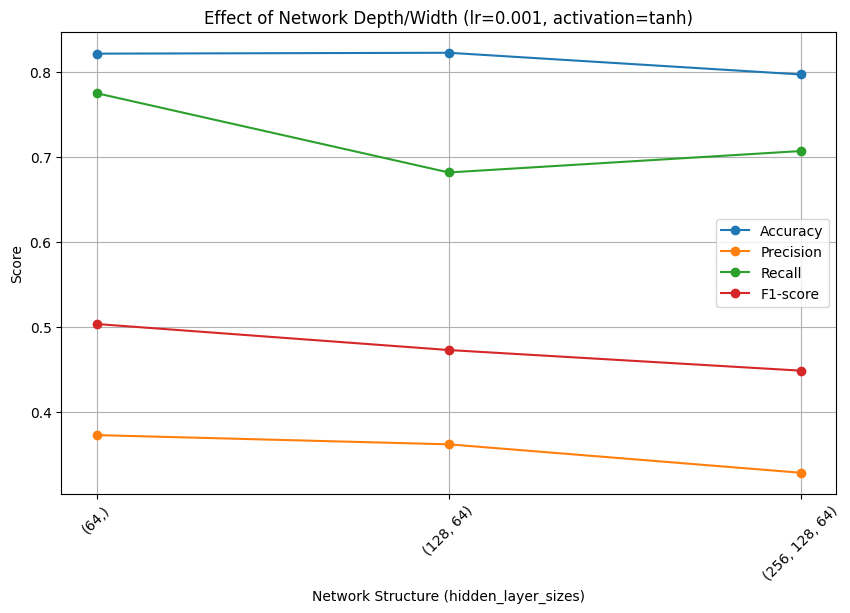

In [52]:
import matplotlib.pyplot as plt

# 固定参数
target_lr = 0.01
target_activation = 'relu'

# 筛选对应实验结果
filtered = [
    r for r in results 
    if r['learning_rate'] == target_lr and r['activation'] == target_activation
]

# 提取数据
labels = [str(r['hidden_layers']) for r in filtered]

acc = [r['val_metrics']['accuracy'] for r in filtered]
prec = [r['val_metrics']['precision'] for r in filtered]
rec = [r['val_metrics']['recall'] for r in filtered]
f1 = [r['val_metrics']['f1'] for r in filtered]

# 画图
plt.figure(figsize=(10,6))
plt.plot(labels, acc, marker='o', label='Accuracy')
plt.plot(labels, prec, marker='o', label='Precision')
plt.plot(labels, rec, marker='o', label='Recall')
plt.plot(labels, f1, marker='o', label='F1-score')

plt.xlabel('Network Structure (hidden_layer_sizes)')
plt.ylabel('Score')
plt.title('Effect of Network Depth/Width (lr=0.001, activation=tanh)')
plt.legend()
plt.xticks(rotation=45)
plt.grid()
plt.show()